# Regional two-reference drift-regime frequency

This plotting-only notebook reads the compact multi-region products written by `0_run_drift_diag.ipynb`. Separate figures are produced for Niño3.4 and the North Atlantic, with global land retained for H2OSOI.

The source panels show stacked fractions for regimes R0–R4. The paired panel shows the corresponding FOSIRL-minus-Reanalysis fraction differences.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import numpy as np
import pandas as pd
import xarray as xr

## 1. Configuration and regime definitions

In [2]:
OUTPUT_ROOT = Path(
    '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/'
    'two_reference'
)
FIGURE_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag')
VARIABLES = ('TREFHT', 'SST', 'PSL', 'PRECT', 'H2OSOI')
INIT_MONTHS = (5, 11)
SOURCES = ('JRA55_FOSIRL', 'Reanalysis')
SOURCE_LABELS = {
    'JRA55_FOSIRL': 'FOSIRL',
    'Reanalysis': 'Reanalysis',
    'paired': 'FOSIRL − Reanalysis',
}
MONTH_NAMES = {5: 'May', 11: 'November'}
PLOT_REGIONS = {
    'TREFHT': ('Nino3.4', 'North_Atlantic'),
    'SST': ('Nino3.4', 'North_Atlantic'),
    'PSL': ('Nino3.4', 'North_Atlantic'),
    'PRECT': ('Nino3.4', 'North_Atlantic'),
    'H2OSOI': ('Global_land',),
}
REGION_LABELS = {
    'Nino3.4': 'Niño3.4 (5°S–5°N, 190°–240°E)',
    'North_Atlantic': 'North Atlantic (0°–60°N, 80°W–0°)',
    'Global_land': 'Global land',
}
REGION_FILE_LABELS = {
    'Nino3.4': 'Nino3_4',
    'North_Atlantic': 'North_Atlantic',
    'Global_land': 'Global_land',
}
REGIME_CODES = (0, 1, 2, 3, 4)
REGIME_LABELS = {
    0: 'R0: neutral / within tolerance',
    1: 'R1: toward observations and attractor',
    2: 'R2: toward observations, away from attractor',
    3: 'R3: away from observations, toward attractor',
    4: 'R4: away from observations and attractor',
}
REGIME_COLORS = {
    0: '0.70',
    1: '#2ca25f',
    2: '#3182bd',
    3: '#f28e2b',
    4: '#d62728',
}
FRACTION_SUM_TOLERANCE = 1.0e-5
FIGURE_DPI = 200
FIGURE_SCALE = 1.0
FIGURE_SIZE = (16.0, 6.4)  # 6:3 (2:1) aspect ratio per panel (3 cols x 2 rows)
SHOW_FIGURES_INLINE = True
FIGURE_PREFIX = 'fig_leadtime_drift_two_reference'
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'figure.titlesize': TITLE_FONT_SIZE,
    'legend.fontsize': LEGEND_FONT_SIZE,
})


def figure_size():
    return tuple(FIGURE_SCALE * value for value in FIGURE_SIZE)


## 2. Load regional regime-frequency products

This section reads only the source-specific multi-region files required for the regime figures. Missing regions must be generated by `0_run_drift_diag.ipynb`.

In [3]:
def regional_product_path(variable, init_month, source):
    return OUTPUT_ROOT / f'{source}_{variable}_{init_month:02d}_regional.nc'


def load_regime_fractions(path, variable, init_month, source):
    names = {f'fraction_regime_{code}' for code in REGIME_CODES}
    with xr.open_dataset(path) as opened:
        missing = names - set(opened.data_vars)
        if missing:
            raise KeyError(f'regional regime fields are missing: {sorted(missing)}')
        dataset = opened[sorted(names)].load()
    expected_regions = PLOT_REGIONS[variable]
    if 'region' not in dataset.dims:
        raise ValueError(
            f'{path} predates multi-region output; rerun '
            'jupyter/0_run_drift_diag.ipynb'
        )
    if tuple(dataset.region.values.astype(str)) != expected_regions:
        raise ValueError('regional coordinate does not match configuration')
    for name in names:
        if dataset[name].dims != ('region', 'L'):
            raise ValueError(f'regional field has invalid dimensions: {name}')
    return dataset


def get_regime_fractions(variable, init_month, source):
    path = regional_product_path(variable, init_month, source)
    if not path.is_file() or path.stat().st_size == 0:
        raise FileNotFoundError(
            f'Missing {path}; run jupyter/0_run_drift_diag.ipynb first'
        )
    dataset = load_regime_fractions(
        path, variable, init_month, source
    )
    print(f'Loaded regional product: {path}')
    return dataset, path, 'loaded'


required_sources = SOURCES + ('paired',)
regime_data = {}
cache_records = []
for variable in VARIABLES:
    for init_month in INIT_MONTHS:
        for source in SOURCES:
            dataset, path, status = get_regime_fractions(
                variable, init_month, source
            )
            regime_data[(variable, init_month, source)] = dataset
            cache_records.append({
                'variable': variable, 'init_month': init_month,
                'source': source, 'status': status, 'path': path,
            })
        fosirl = regime_data[(variable, init_month, 'JRA55_FOSIRL')]
        reanalysis = regime_data[(variable, init_month, 'Reanalysis')]
        paired = xr.Dataset({
            f'delta_fraction_regime_{code}': (
                fosirl[f'fraction_regime_{code}']
                - reanalysis[f'fraction_regime_{code}']
            )
            for code in REGIME_CODES
        })
        paired.attrs['comparison'] = 'JRA55_FOSIRL minus Reanalysis'
        regime_data[(variable, init_month, 'paired')] = paired

loaded_count = sum(r['status'] == 'loaded' for r in cache_records)
print(f'Loaded {loaded_count} source-specific regional products.')

Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_TREFHT_05_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_TREFHT_05_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_TREFHT_11_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_TREFHT_11_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_SST_05_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/Reanalysis_SST_05_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/JRA55_FOSIRL_SST_11_regional.nc
Loaded regional product: /global/cfs/cdirs/e3sm/S

## 3. Validate regime fractions and paired differences

In [4]:
for variable in VARIABLES:
    for init_month in INIT_MONTHS:
        source_fractions = {}
        for source in SOURCES:
            dataset = regime_data[(variable, init_month, source)]
            fractions = xr.concat(
                [dataset[f'fraction_regime_{code}'] for code in REGIME_CODES],
                dim='regime_code',
            )
            total = fractions.sum('regime_code', skipna=False)
            finite = total.where(np.isfinite(total), drop=True)
            if finite.size and float(abs(finite - 1).max()) > FRACTION_SUM_TOLERANCE:
                raise ValueError(
                    f'Regime fractions do not sum to one: {variable}, '
                    f'init={init_month:02d}, {source}'
                )
            source_fractions[source] = dataset
        paired = regime_data[(variable, init_month, 'paired')]
        for code in REGIME_CODES:
            expected = (
                source_fractions['JRA55_FOSIRL'][f'fraction_regime_{code}']
                - source_fractions['Reanalysis'][f'fraction_regime_{code}']
            )
            xr.testing.assert_allclose(
                paired[f'delta_fraction_regime_{code}'], expected
            )
print('Validated source fractions and all paired regime differences.')

Validated source fractions and all paired regime differences.


## 4. Plot regime frequency versus lead

A separate figure is produced for each configured region. Rows distinguish initialization month. The first two columns are stacked source fractions and therefore sum to one at every valid lead. The third column uses the same regime colors for FOSIRL-minus-Reanalysis differences; positive values mean the regime is more frequent in FOSIRL.

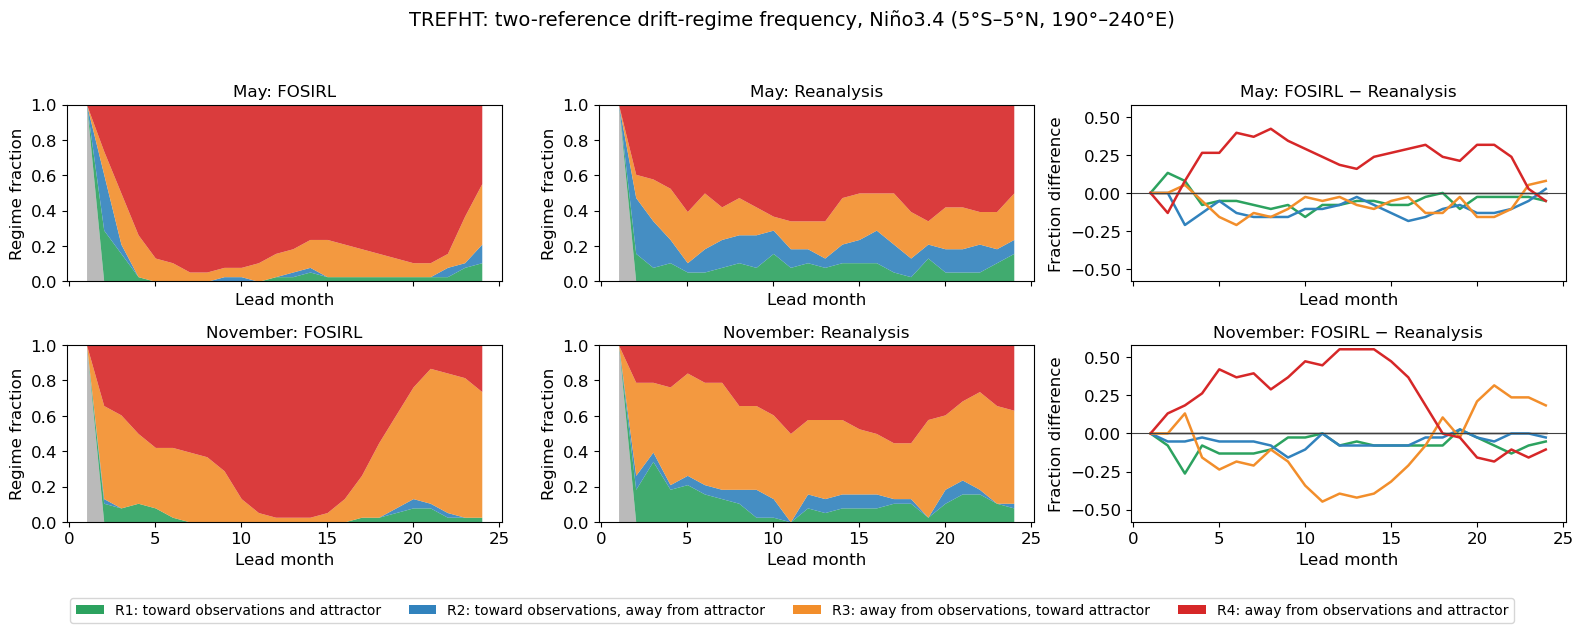

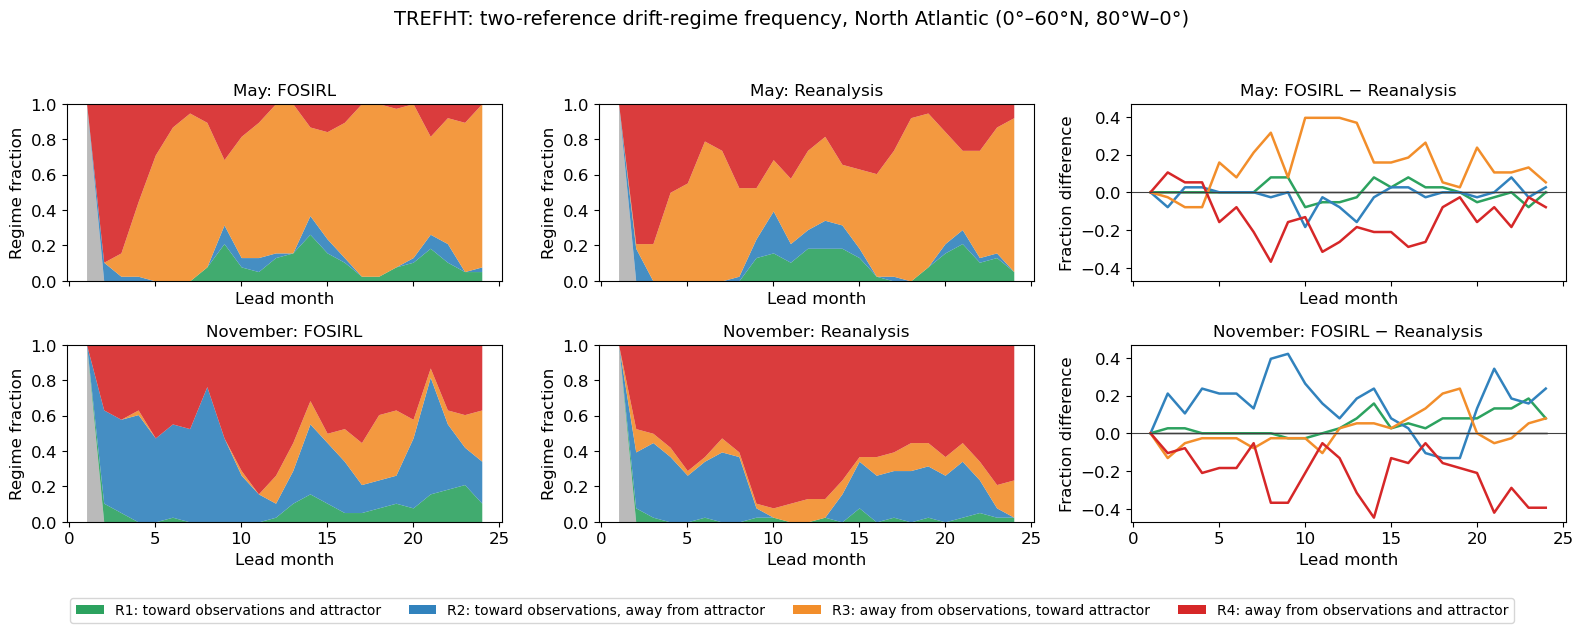

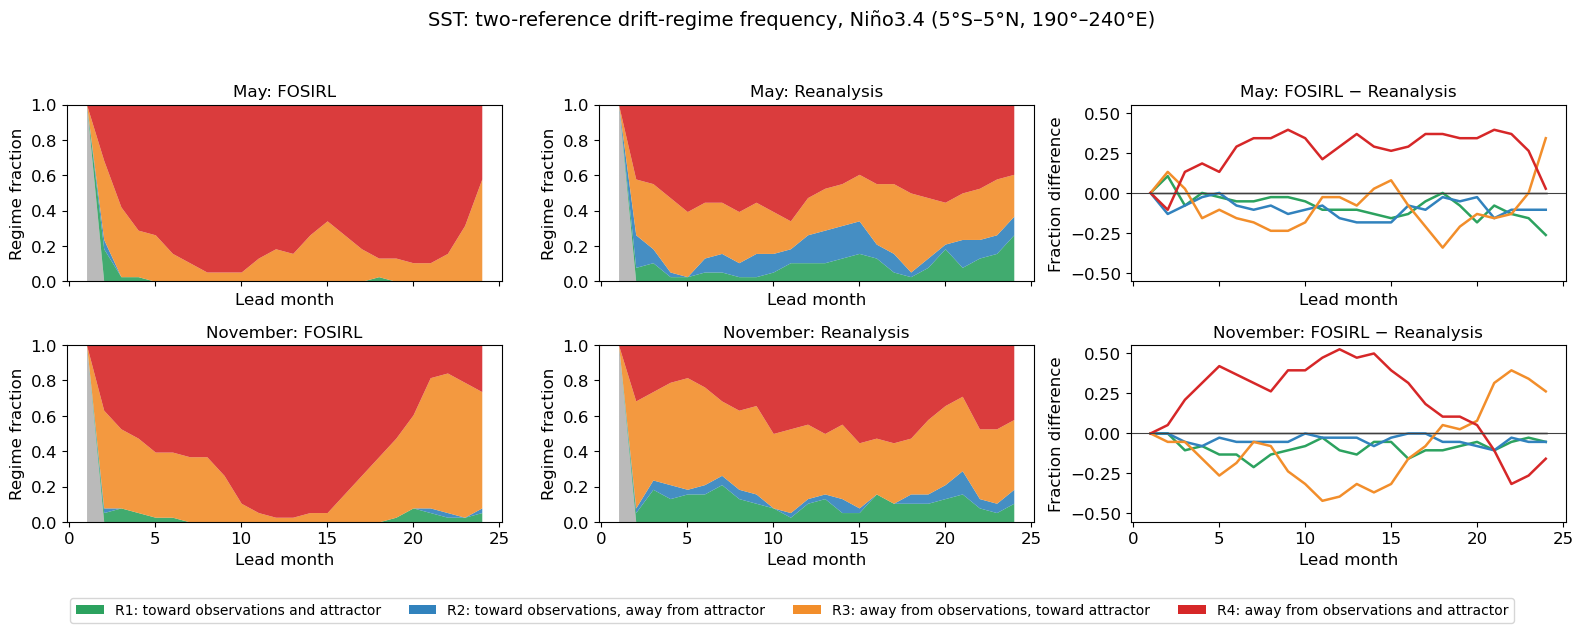

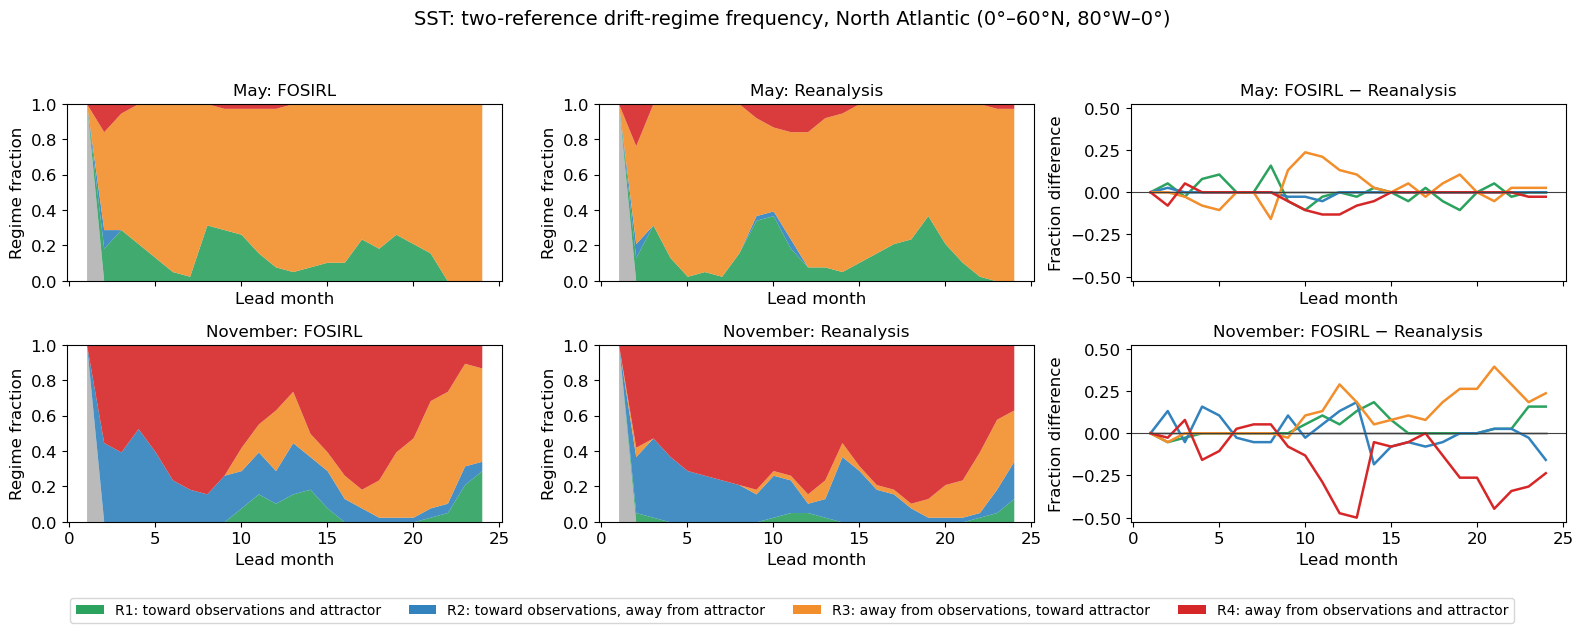

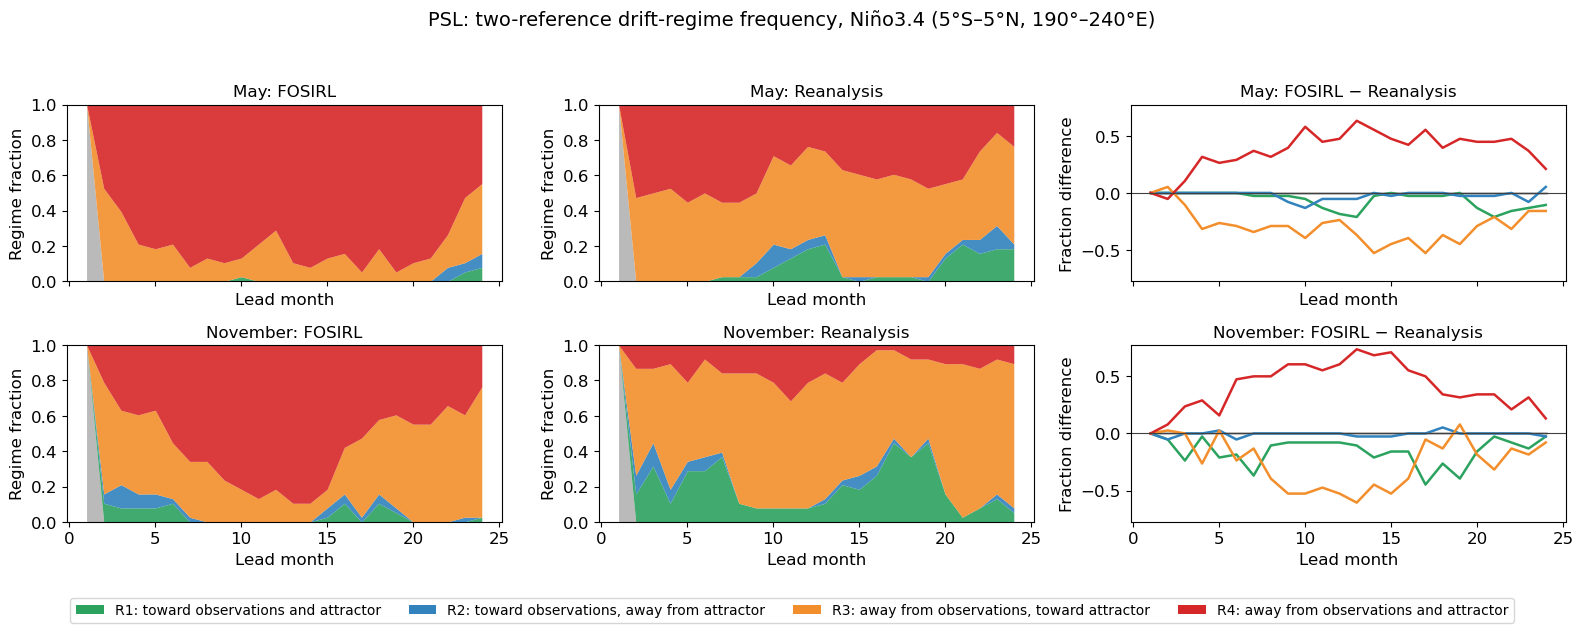

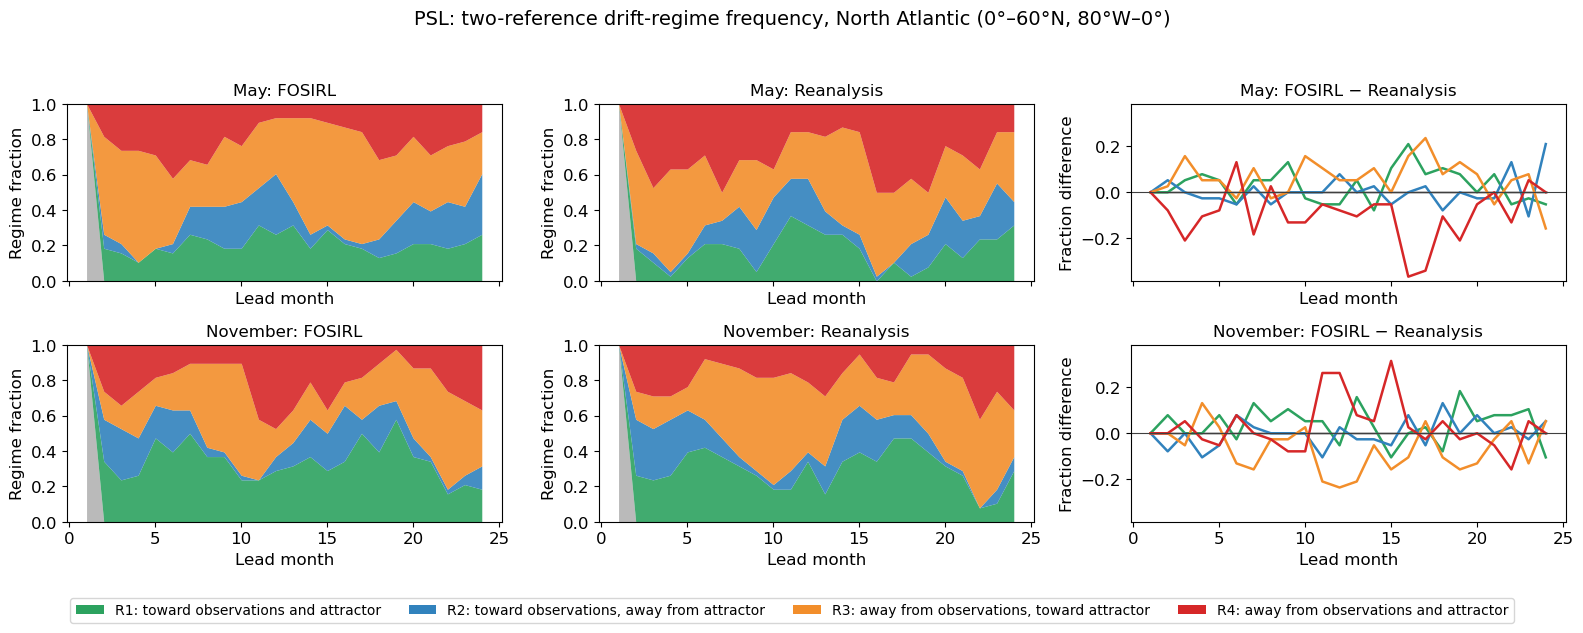

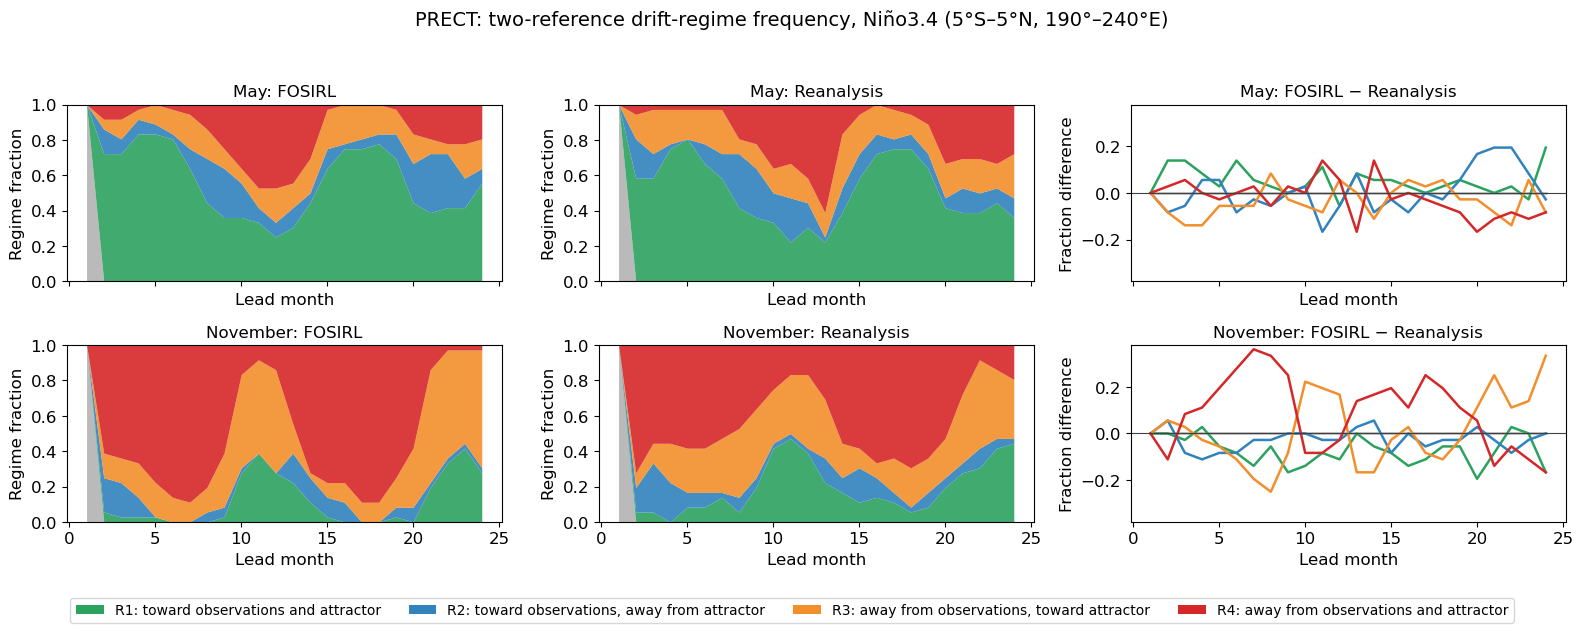

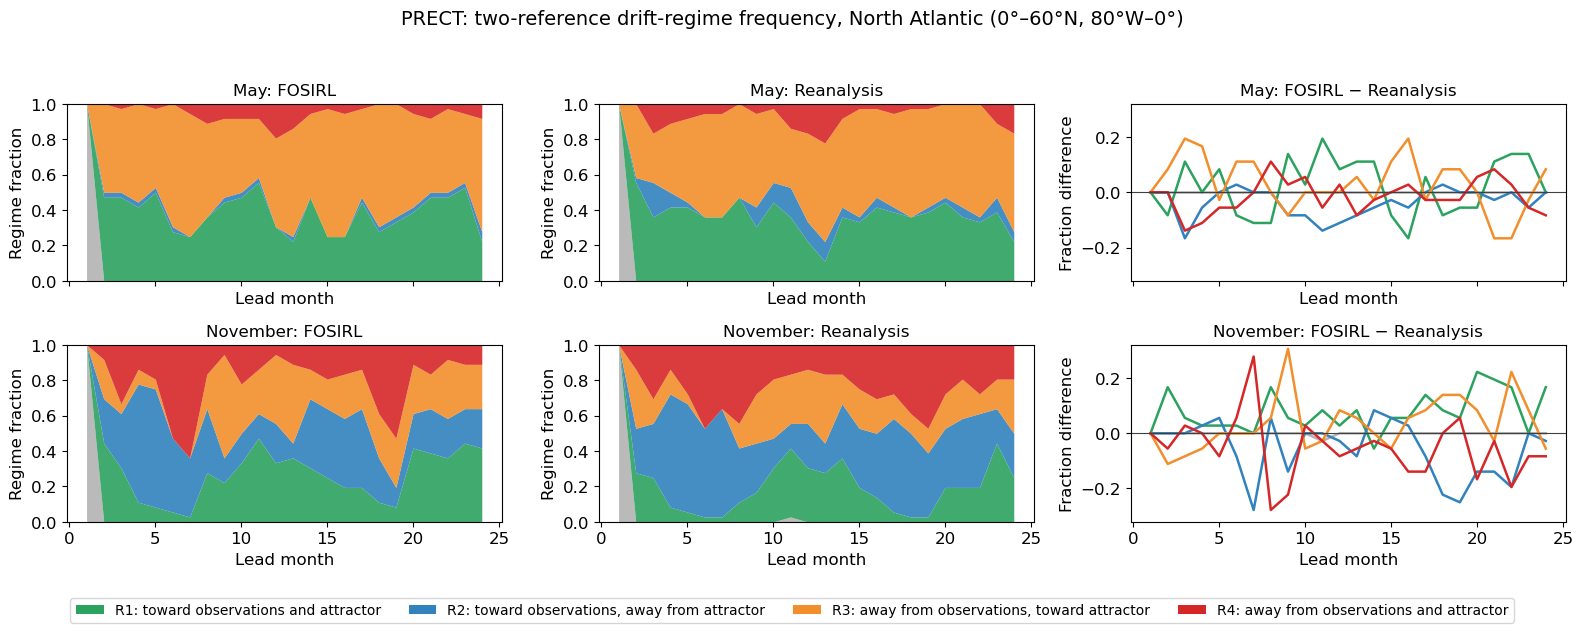

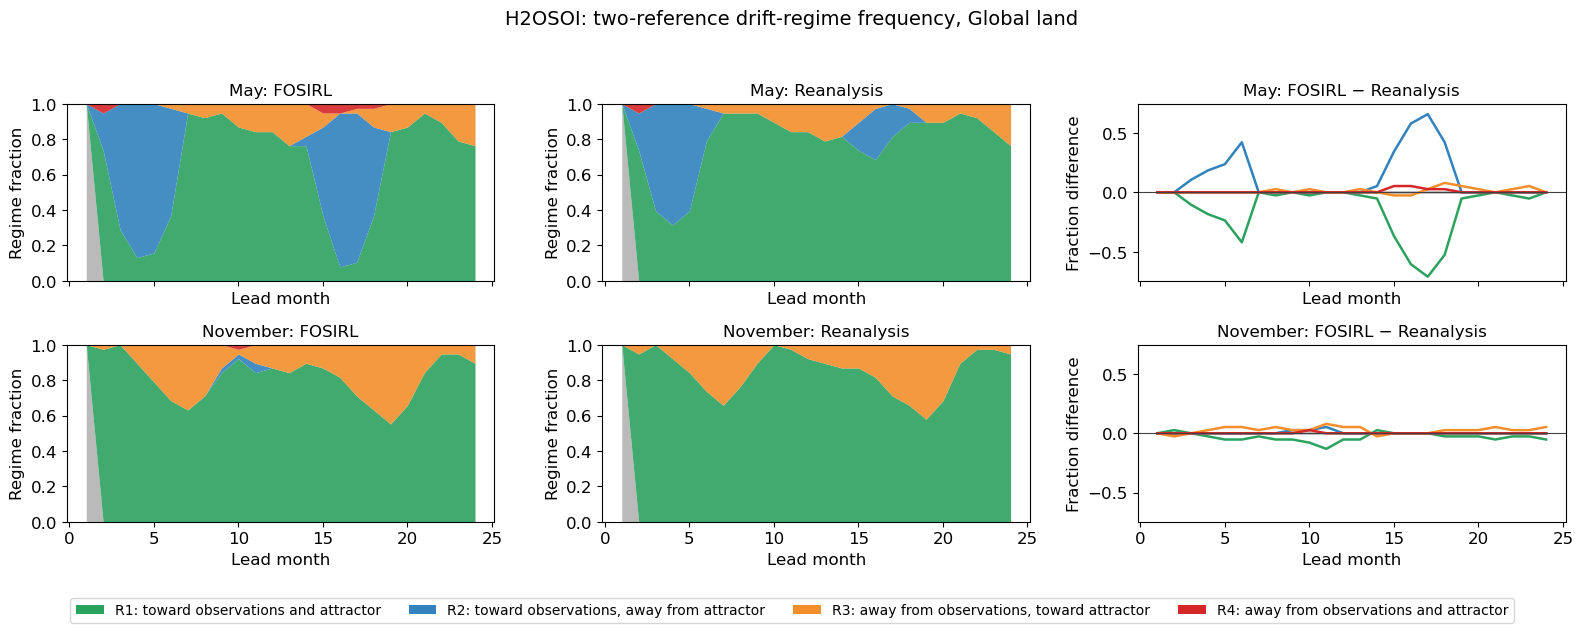

[PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_Nino3_4_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_North_Atlantic_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_Nino3_4_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_North_Atlantic_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_PSL_May_Nov_Nino3_4_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_PSL_May_Nov_North_Atlantic_regime_fraction.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_PRECT_May_Nov_Nino3_4_regime_fraction.png'),
 PosixPath('/global

In [5]:
regime_legend = [
    Patch(facecolor=REGIME_COLORS[code], edgecolor='none',
          label=REGIME_LABELS[code])
    for code in REGIME_CODES
    if code != 0  # Ignore the grey bar (R0 neutral / tolerance) in the legend
]
figure_paths = []
for variable in VARIABLES:
    for region_name in PLOT_REGIONS[variable]:
        paired_fields = [
            regime_data[(variable, init_month, 'paired')][
                f'delta_fraction_regime_{code}'
            ].sel(region=region_name)
            for init_month in INIT_MONTHS
            for code in REGIME_CODES
        ]
        difference_limit = max(
            float(abs(field).max(skipna=True)) for field in paired_fields
        )
        difference_limit = max(0.05, 1.05 * difference_limit)

        fig, axes = plt.subplots(
            len(INIT_MONTHS), 3, figsize=figure_size(),
            sharex=True, squeeze=False, 
        )
        for row, init_month in enumerate(INIT_MONTHS):
            for col, source in enumerate(SOURCES):
                ax = axes[row, col]
                dataset = regime_data[(
                    variable, init_month, source
                )].sel(region=region_name)
                leads = dataset[
                    f'fraction_regime_{REGIME_CODES[0]}'
                ].L.values
                lower = np.zeros(leads.size, dtype=float)
                for code in REGIME_CODES:
                    values = dataset[f'fraction_regime_{code}'].values
                    upper = lower + values
                    ax.fill_between(
                        leads, lower, upper, color=REGIME_COLORS[code],
                        linewidth=0, alpha=0.90,
                    )
                    lower = upper
                ax.set_ylim(0, 1)
                ax.set_ylabel('Regime fraction')
                ax.set_title(
                    f'{MONTH_NAMES[init_month]}: '
                    f'{SOURCE_LABELS[source]}'
                )

            ax = axes[row, 2]
            paired = regime_data[(
                variable, init_month, 'paired'
            )].sel(region=region_name)
            for code in REGIME_CODES:
                paired[f'delta_fraction_regime_{code}'].plot(
                    ax=ax, color=REGIME_COLORS[code], linewidth=1.8,
                    label=f'R{code}',
                )
            ax.axhline(0, color='0.25', linewidth=0.8)
            ax.set_ylim(-difference_limit, difference_limit)
            ax.set_ylabel('Fraction difference')
            ax.set_title(
                f"{MONTH_NAMES[init_month]}: {SOURCE_LABELS['paired']}"
            )
            for col in range(3):
                axes[row, col].set_xlabel('Lead month')

        fig.legend(
            handles=regime_legend, loc='lower center', ncol=4,
            bbox_to_anchor=(0.5, 0.01), frameon=True,
            fontsize=LEGEND_FONT_SIZE,
        )
        fig.suptitle(
            f'{variable}: two-reference drift-regime frequency, '
            f'{REGION_LABELS[region_name]}'
        )
        fig.tight_layout(rect=[0, 0.08, 1, 0.95])
        path = FIGURE_ROOT / (
            f'{FIGURE_PREFIX}_{variable}_May_Nov_'
            f'{REGION_FILE_LABELS[region_name]}_regime_fraction.png'
        )
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
        if SHOW_FIGURES_INLINE:
            display(fig)
        plt.close(fig)
        figure_paths.append(path)

figure_paths


## 5. Output validation

In [6]:
expected_figure_count = sum(
    len(PLOT_REGIONS[variable]) for variable in VARIABLES
)
assert len(figure_paths) == expected_figure_count
assert all(path.is_file() and path.stat().st_size > 0 for path in figure_paths)
assert len(regime_data) == (
    len(VARIABLES) * len(INIT_MONTHS) * len(required_sources)
)
assert len(cache_records) == len(VARIABLES) * len(INIT_MONTHS) * len(SOURCES)
assert all(r['path'].is_file() and r['path'].stat().st_size > 0 for r in cache_records)
for (variable, _, _), dataset in regime_data.items():
    available = set(dataset.region.values.astype(str))
    assert set(PLOT_REGIONS[variable]) <= available
print(
    f'Validated {len(figure_paths)} regime-frequency figures from '
    f'{len(cache_records)} source-specific regional products.'
)

Validated 9 regime-frequency figures from 20 source-specific regional products.
